In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DFsvm.xlsx to DFsvm (1).xlsx


In [ ]:
"""
Módulo Support Vector Machine (SVM)
============================

Este módulo implementa o algoritmo de Máquina de Vetores de Suporte aplicado a
dados de exoplanetas previamente tratados, agrupados e pseudo-rotulados.

Utilizando o os rótulos e o agrupamento prévios busca-se aqui classificar os
exoplanetas avaliando suas características.............. (re)escrever e adicionar
o que mais for relevante

Inclui:
- Separação de dados para SVM
- Treinamento do modelo
- Avaliação e correções no conjunto de ajuste
- Avaliação no conjunto de testes
- Captura dos nomes dos exoplanetas
- Análise detalhada dos erros do modelo
- Estatísticas por tipo de erro (VP, VN, FP, FN)
- Salvar resultados completos

"""
import sys
sys.path.append("/content/drive/MyDrive/Notebooks-Colab/IC-Notebooks/src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [ ]:
def separacao_de_dados(df, rotulos):
    """
    5.0 Separar dados em conjuntos para o SVM
    =======================================

    Realiza a divisão dos dados em treino (75%), ajuste (15%) e teste (10%),
    mantendo controle dos índices originais.

    Parameters
    ----------
    df : DataFrame ou ndarray
        Dados de entrada (features)
    rotulos : ndarray
        Rótulos correspondentes

    Returns
    -------
    X_train, X_adj, X_test : ndarray
        Dados de treino, ajuste e teste
    y_train, y_adj, y_test : ndarray
        Rótulos de treino, ajuste e teste
    idx_test : ndarray
        Índices dos dados de teste no dataset original
    """

    print("PREPARANDO DADOS PARA SVM:")
    print(f"Shape dos dados: {df.shape}")
    print(f"Distribuição dos rótulos: {pd.Series(rotulos).value_counts().to_dict()}")

    indices = np.arange(len(df))

    # Primeiro split
    X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
        df, rotulos, indices,
        test_size=0.25,
        random_state=57,
        stratify=rotulos
    )

    # Segundo split
    X_adj, X_test, y_adj, y_test, idx_adj, idx_test = train_test_split(
        X_temp, y_temp, idx_temp,
        test_size=0.4,
        random_state=57,
        stratify=y_temp
    )

    print("\nDIVISÃO 75-15-10:")
    print(f"Treino: {len(X_train)}")
    print(f"Ajuste: {len(X_adj)}")
    print(f"Teste: {len(X_test)}")

    return X_train, X_adj, X_test, y_train, y_adj, y_test, idx_test

In [ ]:
def treinamento_modelo_svm(dados_treino, rotulos_treino, C=1.0, gamma='scale'):
    """
    5.1 Treinamento do Modelo
    =========================

    Executa o treinamento do modelo SVM com os dados e os rótulos de treino.

    Parameters
    ----------
    dados_treino : ndarray
        Dados de treino para o SVM
    rotulos_treino : ndarray
        Rótulos de treino para o SVM
    C : float, optional
        Parâmetro de regularização do SVM (default=1.0)
    gamma : str or float, optional
        Parâmetro do kernel RBF (default='scale')

    Returns
    -------
    modelo_svm : SVC
        Modelo SVM treinado
    """

    modelo_svm = SVC(
        kernel='rbf',
        C=C,
        gamma=gamma,
        random_state=57
    )

    modelo_svm.fit(dados_treino, rotulos_treino)

    return modelo_svm

In [ ]:
def avaliacao_modelo(modelo, dados, rotulos, nome_conjunto, plotar=True):
    """
    5.2 Avaliação do modelo SVM
    ==========================

    Avalia o modelo SVM em um conjunto de dados (ajuste ou teste),
    exibindo matriz de confusão, relatório de classificação e acurácia.

    Parameters
    ----------
    modelo : SVC
        Modelo SVM treinado
    dados : ndarray
        Dados para avaliação
    rotulos : ndarray
        Rótulos reais
    nome_conjunto : str
        Nome do conjunto (ex: "Ajuste", "Teste Final")
    plotar : bool, optional
        Define se a matriz de confusão será exibida (default=True)

    Returns
    -------
    previsoes : ndarray
        Rótulos preditos pelo modelo
    matriz : ndarray
        Matriz de confusão
    acuracia : float
        Acurácia do modelo
    """

    print(f"\nAVALIAÇÃO - {nome_conjunto.upper()}")

    previsoes = modelo.predict(dados)
    matriz = confusion_matrix(rotulos, previsoes)

    if plotar:
        plt.figure(figsize=(6, 5))
        sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['NT', 'TT'],
                    yticklabels=['NT', 'TT'])
        plt.title(f'Matriz de Confusão - SVM ({nome_conjunto})')
        plt.tight_layout()
        plt.show()

    print(f"\nRELATÓRIO DE CLASSIFICAÇÃO ({nome_conjunto}):")
    print(classification_report(rotulos, previsoes,
                                target_names=["Não-Terrestre", "Terrestre"]))

    acuracia = accuracy_score(rotulos, previsoes)
    print(f"Acurácia: {acuracia:.3f}")

    return previsoes, matriz, acuracia

In [ ]:
def captura_nomes_exoplanetas(df, idx_teste, rotulos_teste, previsoes):
    """
    5.3 Capturar nomes dos exoplanetas
    ================================

    Associa os nomes dos exoplanetas com os resultados de classificação
    no conjunto de teste.

    Parameters
    ----------
    df : DataFrame
        DataFrame original com os dados dos exoplanetas
    idx_teste : ndarray
        Índices dos dados de teste
    rotulos_teste : ndarray
        Rótulos reais
    previsoes : ndarray
        Rótulos preditos pelo modelo

    Returns
    -------
    tabela_resultados_finais : DataFrame
        Tabela com resultados detalhados
    """

    nomes_planetas = df.iloc[idx_teste]['pl_name'].values

    tabela_resultados_finais = pd.DataFrame({
        'nome_planeta': nomes_planetas,
        'rotulo_original': rotulos_teste,
        'rotulo_predito': previsoes,
        'previsao_correta': rotulos_teste == previsoes
    })

    # Mapear categorias
    tabela_resultados_finais['categoria_original'] = tabela_resultados_finais['rotulo_original'].map({
        0: 'Não-Terrestre', 1: 'Terrestre'
    })

    tabela_resultados_finais['categoria_predita'] = tabela_resultados_finais['rotulo_predito'].map({
        0: 'Não-Terrestre', 1: 'Terrestre'
    })

    print("\nRESULTADOS FINAIS DETALHADOS:")
    print(f"Total: {len(tabela_resultados_finais)}")
    print(f"Corretos: {tabela_resultados_finais['previsao_correta'].sum()}")
    print(f"Acurácia: {tabela_resultados_finais['previsao_correta'].mean():.3f}")

    print("\nAMOSTRA:")
    for _, row in tabela_resultados_finais.head(10).iterrows():
        status = "CORRETO" if row['previsao_correta'] else "ERRADO"
        print(f"{row['nome_planeta']:30} | {status}")

    return tabela_resultados_finais

In [ ]:
def analise_detalhada_erros(tabela_resultados_finais, matriz_confusao):
    """
    5.4 Análise detalhada dos erros
    ==============================

    Analisa os erros de classificação e apresenta estatísticas detalhadas.

    Parameters
    ----------
    tabela_resultados_finais : DataFrame
        Tabela com resultados da classificação
    matriz_confusao : ndarray
        Matriz de confusão do modelo
    """

    # Filtrar erros
    erros = tabela_resultados_finais[~tabela_resultados_finais['previsao_correta']]

    if len(erros) > 0:
        print(f"\nANÁLISE DOS ERROS ({len(erros)} planetas):")
        for _, row in erros.iterrows():
            print(f"   {row['nome_planeta']:30} | Classificado como {row['categoria_predita']} mas era {row['categoria_original']}")
    else:
        print("\nNENHUM ERRO ENCONTRADO - TODAS AS PREVISÕES ESTÃO CORRETAS!")

    # Estatísticas
    print("\nESTATÍSTICAS DETALHADAS:")

    vp = matriz_confusao[1, 1]  # Verdadeiros positivos
    vn = matriz_confusao[0, 0]  # Verdadeiros negativos
    fp = matriz_confusao[0, 1]  # Falsos positivos
    fn = matriz_confusao[1, 0]  # Falsos negativos

    print(f"Planetas terrestres corretamente classificados: {vp} (VP)")
    print(f"Planetas não-terrestres corretamente classificados: {vn} (VN)")
    print(f"Falsos Positivos: {fp}")
    print(f"Falsos Negativos: {fn}")

In [ ]:
def salvar_resultados_completos(tabela_resultados_finais):
  """
    5.9 Salvar resultados completos
    ==============================

    Salva os resultados detalhados da classificação em um arquivo CSV
    e exibe a acurácia final do modelo.

    Parameters
    ----------
    tabela_resultados_finais : DataFrame
        Tabela contendo os resultados finais da classificação,
        incluindo nomes dos planetas, categorias e acertos

    Returns
    -------
    DataFrame
        Retorna a própria tabela de resultados finais
  """
  tabela_resultados_finais[['nome_planeta', 'categoria_original', 'categoria_predita', 'previsao_correta']].to_csv('resultados_classificacao_exoplanetas_detalhado.csv', index=False)
  print()
  print("Resultados detalhados salvos em 'resultados_classificacao_exoplanetas_detalhado.csv'")

  print()
  print(f"Acurácia final do modelo em dados nunca vistos: {acuracia_final:.1%}")

  return tabela_resultados_finais

In [ ]:
def executar_svm(df_features, df_original):
  """
    5.10 Pipeline completo do SVM
    ===========================

    Executa todo o pipeline de classificação utilizando o modelo SVM,
    incluindo separação dos dados, treinamento, avaliação e análise
    dos resultados.

    Parameters
    ----------
    df_features : DataFrame
        DataFrame contendo as variáveis preditoras (features) do modelo
    df_original : DataFrame
        DataFrame original contendo os dados completos, incluindo os rótulos
        na coluna 'label_lp'

    Returns
    -------
    modelo : objeto
        Modelo SVM treinado
    tabela : DataFrame
        Tabela com os resultados finais da classificação para o conjunto de teste

    Raises
    ------
    ValueError
        Caso a coluna 'label_lp' não esteja presente no DataFrame original
  """
  if "label_lp" not in df_original.columns:
    raise ValueError("O DataFrame precisa conter a coluna 'label_lp' referente aos rótulos")

  rotulos = df_original["label_lp"].values

  X_train, X_adj, X_test, y_train, y_adj, y_test, idx_test = separacao_de_dados(
    df_features.values, rotulos)

  modelo = treinamento_modelo_svm(X_train, y_train)

  avaliacao_modelo(modelo, X_adj, y_adj, "Ajuste")

  previsoes_test, matriz_test, acuracia_final = avaliacao_modelo(modelo, X_test, y_test, "Teste Final")

  tabela = captura_nomes_exoplanetas(df_original, idx_test, y_test, previsoes_test)

  analise_detalhada_erros(tabela, matriz_test)

  salvar_resultados_completos(tabela, acuracia_final)

  return modelo, tabela

In [ ]:
def salvar_resultados_completos(tabela_resultados_finais, acuracia_final):
    """
    5.9 Salvar resultados completos
    ==============================

    Salva os resultados detalhados da classificação em um arquivo CSV
    e exibe a acurácia final do modelo.

    Parameters
    ----------
    tabela_resultados_finais : DataFrame
        Tabela contendo os resultados finais da classificação,
        incluindo nome dos planetas, categorias e indicação de acerto
    acuracia_final : float
        Valor da acurácia final do modelo no conjunto de teste

    Returns
    -------
    DataFrame
        Retorna a tabela de resultados finais
    """

    tabela_resultados_finais[
        ['nome_planeta', 'categoria_original', 'categoria_predita', 'previsao_correta']
    ].to_csv('resultados_classificacao_exoplanetas_detalhado.csv', index=False)

    print("\nResultados detalhados salvos em 'resultados_classificacao_exoplanetas_detalhado.csv'")
    print(f"Acurácia final do modelo em dados nunca vistos: {acuracia_final:.1%}")

    return tabela_resultados_finais

In [ ]:
def preparar_features(df):
    """
    Remove colunas que não devem entrar no modelo
    """

    colunas_excluir = ["pl_name", "cluster_hc", "PC1", "PC2", "label_lp"]

    colunas_features = [col for col in df.columns if col not in colunas_excluir]

    return df[colunas_features]

In [ ]:
def main(caminho_entrada, caminho_saida="resultados_svm.csv"):

    df = pd.read_excel(caminho_entrada)

    print("Dataset carregado com sucesso")
    print("Shape:", df.shape)

    df_features = preparar_features(df)

    modelo, tabela = executar_svm(df_features, df)

    print(f"\nResultados salvos em: {caminho_saida}")

    return modelo, tabela

Dataset carregado com sucesso
Shape: (2739, 8)
PREPARANDO DADOS PARA SVM:
Shape dos dados: (2739, 5)
Distribuição dos rótulos: {0: 2163, 1: 576}

DIVISÃO 75-15-10:
Treino: 2054
Ajuste: 411
Teste: 274

AVALIAÇÃO - AJUSTE


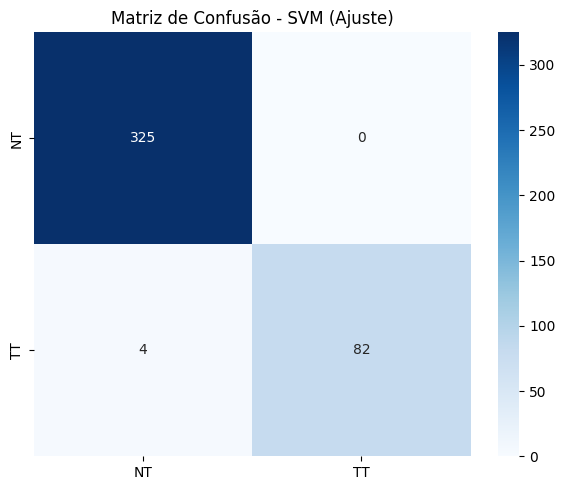


RELATÓRIO DE CLASSIFICAÇÃO (Ajuste):
               precision    recall  f1-score   support

Não-Terrestre       0.99      1.00      0.99       325
    Terrestre       1.00      0.95      0.98        86

     accuracy                           0.99       411
    macro avg       0.99      0.98      0.99       411
 weighted avg       0.99      0.99      0.99       411

Acurácia: 0.990

AVALIAÇÃO - TESTE FINAL


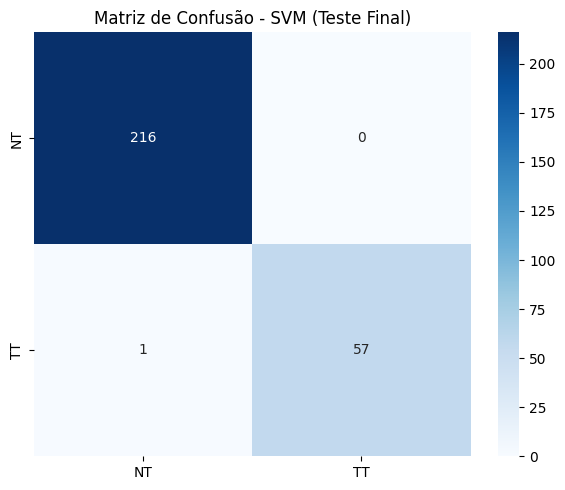


RELATÓRIO DE CLASSIFICAÇÃO (Teste Final):
               precision    recall  f1-score   support

Não-Terrestre       1.00      1.00      1.00       216
    Terrestre       1.00      0.98      0.99        58

     accuracy                           1.00       274
    macro avg       1.00      0.99      0.99       274
 weighted avg       1.00      1.00      1.00       274

Acurácia: 0.996

RESULTADOS FINAIS DETALHADOS:
Total: 274
Corretos: 273
Acurácia: 0.996

AMOSTRA:
Kepler-676 b                   | CORRETO
K2-19 b                        | CORRETO
Kepler-1969 b                  | CORRETO
Kepler-306 b                   | CORRETO
Kepler-1217 b                  | CORRETO
Kepler-1184 b                  | CORRETO
Kepler-581 b                   | CORRETO
Kepler-122 d                   | CORRETO
Kepler-430 b                   | CORRETO
Kepler-306 e                   | CORRETO

ANÁLISE DOS ERROS (1 planetas):
   HD 168009 b                    | Classificado como Não-Terrestre mas era Terrest

In [ ]:
modelo, resultados_svm = main(
    caminho_entrada="DFsvm.xlsx",
    caminho_saida="resultados_svm.csv"
)